# HW1: Global Asset Causal Networks & Return Forecasting

**Authors:** Lucas Salamanca, Nicolas Koutalakis, Lorenzo
**Course:** ML in Finance — Spring 2026


## 0. Setup & Libraries

In [2]:
import importlib

REQUIRED_MODULES = {
    "yfinance": "yfinance",
    "pandas": "pandas",
    "numpy": "numpy",
    "statsmodels": "statsmodels",
    "arch": "arch",
    "scikit-learn": "sklearn",
    "tensorflow": "tensorflow",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "networkx": "networkx",
    "dcor": "dcor",
    "scipy": "scipy",
    "tabulate": "tabulate",
}

missing = []
for package, module in REQUIRED_MODULES.items():
    try:
        importlib.import_module(module)
    except ImportError:
        missing.append(package)

if missing:
    print("Missing packages:", missing)
    print("Use the Jupyter kernel 'Python 3.11 (ML Finance HW1)' or install the packages above.")
else:
    print("All required packages are available in this kernel.")


All required packages are available in this kernel.


In [3]:
import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests, adfuller, ccf
from statsmodels.tsa.arima.model import ARIMA

from arch import arch_model

from sklearn.linear_model import Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, DotProduct
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import networkx as nx
import dcor
import scipy.stats as stats
from tabulate import tabulate
import yfinance as yf

%matplotlib inline
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = Path("Hw1") if Path("Hw1").exists() else Path(".")
print(f"NumPy {np.__version__} | Pandas {pd.__version__} | TF {tf.__version__}")
print(f"Data directory: {DATA_DIR.resolve()}")
print("Imports complete.")


NumPy 2.4.4 | Pandas 3.0.2 | TF 2.21.0
Data directory: C:\Users\utente\Documents\PYTHON_VSC\ML_Finance\Hw1
Imports complete.


---
## 1. Problem 1: Global Asset Causal Network (35%)

**Objective:** Estimate directed causal relationships among 10 global assets using Granger causality, then visualise the resulting networks.

**Assets:** SPY (S&P 500), XLK (Technology), XLF (Financials), XLE (Energy), GLD (Gold), SLV (Silver), GSG (Broad Commodities), BTC-USD, ETH-USD, TLT (20+ Year Treasuries).

**Default period in this notebook:** 2024-01-01 to 2025-12-31. If the team spreadsheet assigns a different epoch, change `START_DATE` and `END_DATE` below before running the analysis.

**Implementation notes from HW1 Tips / Lab 3:**
- Use `VAR.select_order(...).selected_orders["aic"]` with candidate lags 1-5.
- In `statsmodels.grangercausalitytests`, the first column is the affected/endogenous variable and the second column is the proposed causal variable.
- Build four row-to-column tables: weekly returns, monthly returns, weekly EWMA volatility, monthly EWMA volatility. Entry `l` means row asset Granger-causes column asset at lag `l`; `0` means not significant at 5%.


### 1.1 Data Download - Daily Adjusted Close Prices (Yahoo Finance)

In [4]:
ASSETS = ["SPY", "XLK", "XLF", "XLE", "GLD", "SLV", "GSG", "BTC-USD", "ETH-USD", "TLT"]
START_DATE = "2024-01-01"
END_DATE = "2025-12-31"
DOWNLOAD_END_DATE = (pd.Timestamp(END_DATE) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
P1_CSV = DATA_DIR / f"assets_{START_DATE}_{END_DATE}.csv".replace(":", "-")
FORCE_DOWNLOAD = False

if P1_CSV.exists() and not FORCE_DOWNLOAD:
    prices = pd.read_csv(P1_CSV, index_col=0, parse_dates=True)
    prices = prices.reindex(columns=ASSETS)
    print(f"Loaded cached prices from {P1_CSV} | shape={prices.shape}")
else:
    raw = yf.download(
        ASSETS,
        start=START_DATE,
        end=DOWNLOAD_END_DATE,   # Yahoo's end date is exclusive
        auto_adjust=True,
        progress=False,
        group_by="column",
    )

    if isinstance(raw.columns, pd.MultiIndex):
        if "Close" in raw.columns.get_level_values(0):
            prices = raw["Close"].copy()
        else:
            prices = raw.xs("Close", axis=1, level=-1).copy()
    else:
        prices = raw.copy()

    prices.index = pd.to_datetime(prices.index)
    prices.columns.name = None
    prices = prices.reindex(columns=ASSETS)
    prices.to_csv(P1_CSV)
    print(f"Downloaded and saved prices to {P1_CSV} | shape={prices.shape}")

missing = prices.isna().sum()
miss_df = pd.DataFrame({
    "Missing rows": missing,
    "Pct %": (missing / len(prices) * 100).round(2),
})
print("\nMissing values per asset before cleaning:")
print(tabulate(miss_df, headers="keys", tablefmt="rounded_outline"))

# Crypto trades every day, while ETFs do not. Forward-fill lets weekly/monthly
# resampling use the last available ETF close on non-trading calendar days.
prices_clean = prices.sort_index().ffill().dropna(how="any")
prices_clean = prices_clean.loc[START_DATE:END_DATE]

print(f"\nClean price panel: {prices_clean.shape}")
print(f"Date range: {prices_clean.index.min().date()} to {prices_clean.index.max().date()}")
print("\nClose price summary statistics:")
print(tabulate(prices_clean.describe().round(2), headers="keys", tablefmt="rounded_outline"))


Loaded cached prices from assets_2024-01-01_2025-12-31.csv | shape=(731, 10)

Missing values per asset before cleaning:
╭─────────┬────────────────┬─────────╮
│         │   Missing rows │   Pct % │
├─────────┼────────────────┼─────────┤
│ SPY     │            229 │   31.33 │
│ XLK     │            229 │   31.33 │
│ XLF     │            229 │   31.33 │
│ XLE     │            229 │   31.33 │
│ GLD     │            229 │   31.33 │
│ SLV     │            229 │   31.33 │
│ GSG     │            229 │   31.33 │
│ BTC-USD │              0 │    0    │
│ ETH-USD │              0 │    0    │
│ TLT     │            229 │   31.33 │
╰─────────┴────────────────┴─────────╯

Clean price panel: (730, 10)
Date range: 2024-01-02 to 2025-12-31

Close price summary statistics:
╭───────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬───────────┬───────────┬────────╮
│       │    SPY │    XLK │    XLF │    XLE │    GLD │    SLV │    GSG │   BTC-USD │   ETH-USD │    TLT │
├───────┼────────┼────

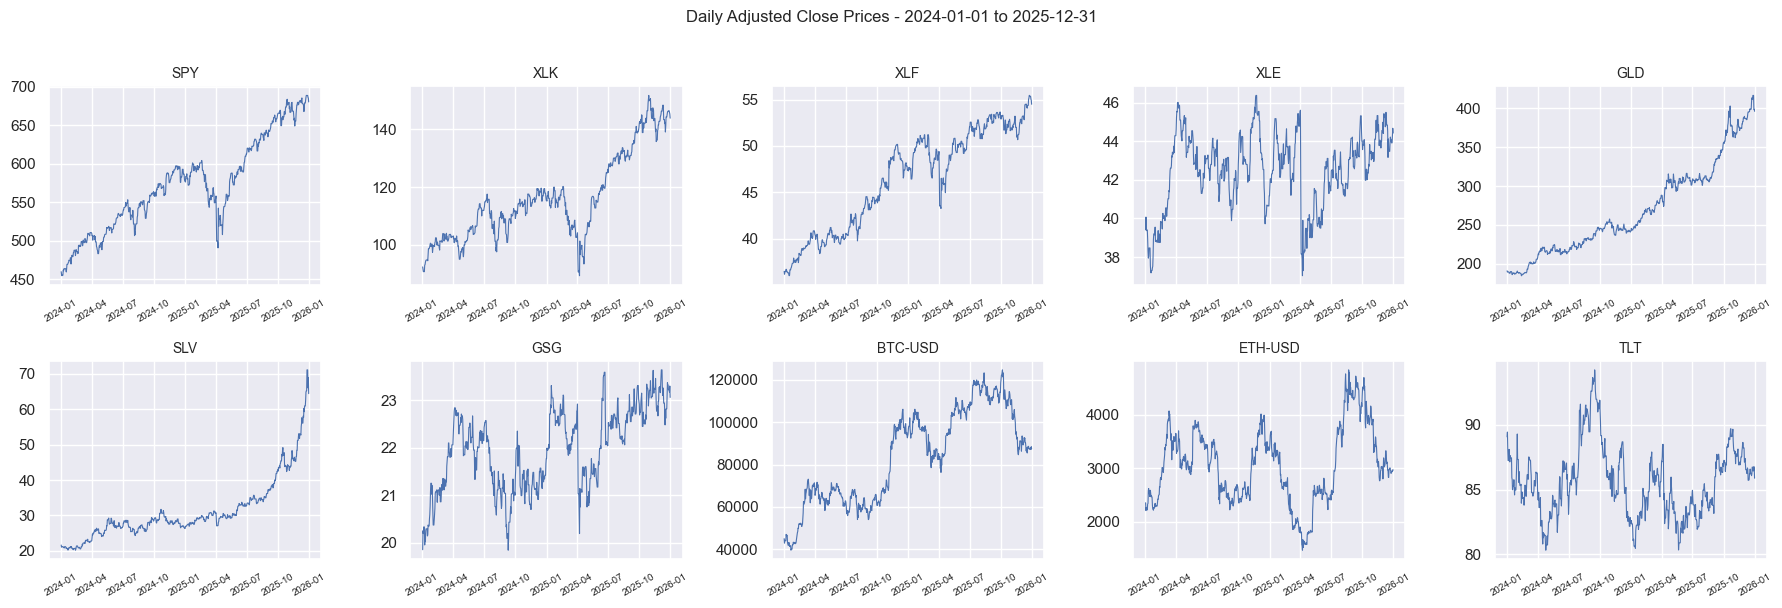

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharex=False)
axes = axes.flatten()
for i, col in enumerate(ASSETS):
    axes[i].plot(prices_clean.index, prices_clean[col], lw=0.8)
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis="x", rotation=30, labelsize=7)

plt.suptitle(f"Daily Adjusted Close Prices - {START_DATE} to {END_DATE}", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


### 1.2 Returns, EWMA Volatility, Pairwise Granger Tables, and Networks

In [6]:
ALPHA = 0.05
MAX_LAG = 5
EWMA_LAMBDA = 0.94


def resample_price_panel(price_panel, freq):
    """Last available price in each weekly/monthly period, clipped to the assigned epoch."""
    sampled = price_panel.resample(freq).last().ffill().dropna(how="any")
    return sampled.loc[:pd.Timestamp(END_DATE)]


def log_returns(price_panel):
    return np.log(price_panel).diff().dropna(how="any")


def ewma_volatility(return_panel, lambda_=EWMA_LAMBDA):
    """EWMA volatility sqrt(EWMA(r^2)); lambda=0.94 follows the usual RiskMetrics/Lab setup."""
    return return_panel.pow(2).ewm(alpha=1 - lambda_, adjust=False).mean().pow(0.5).dropna(how="any")


def _select_aic_lag(pair_data, max_lag=MAX_LAG):
    """Select an AIC lag in [1, max_lag] for one asset pair using VAR.select_order."""
    pair_data = pair_data.dropna()
    if pair_data.shape[0] < 8 or pair_data.nunique().min() <= 1:
        return None

    feasible_max = min(max_lag, max(1, (pair_data.shape[0] - 1) // 4))
    for trial_max in range(feasible_max, 0, -1):
        try:
            selected = VAR(pair_data).select_order(maxlags=trial_max, trend="n").selected_orders.get("aic")
            if selected is None or pd.isna(selected):
                selected = 1
            return int(min(max(int(selected), 1), trial_max))
        except Exception:
            continue
    return None


def _granger_pvalue(pair_data, lag):
    """Statsmodels tests whether column 2 Granger-causes column 1."""
    try:
        result = grangercausalitytests(pair_data, maxlag=lag, verbose=False)
        return float(result[lag][0]["ssr_ftest"][1])
    except Exception:
        return np.nan


def build_causality_table(series_panel, assets=ASSETS, alpha=ALPHA, max_lag=MAX_LAG):
    """
    Return row-to-column lag and p-value matrices.
    Entry lag_table.loc[cause, effect] = selected lag if cause -> effect is significant, else 0.
    """
    lag_table = pd.DataFrame(0, index=assets, columns=assets, dtype=int)
    pvalue_table = pd.DataFrame(np.nan, index=assets, columns=assets, dtype=float)
    selected_lag_table = pd.DataFrame(np.nan, index=assets, columns=assets, dtype=float)

    for cause in assets:
        for effect in assets:
            if cause == effect:
                continue
            pair = series_panel[[effect, cause]].replace([np.inf, -np.inf], np.nan).dropna()
            lag = _select_aic_lag(pair, max_lag=max_lag)
            if lag is None:
                continue
            pvalue = _granger_pvalue(pair, lag)
            selected_lag_table.loc[cause, effect] = lag
            pvalue_table.loc[cause, effect] = pvalue
            if np.isfinite(pvalue) and pvalue < alpha:
                lag_table.loc[cause, effect] = lag

    return lag_table, pvalue_table, selected_lag_table


def display_lag_table(lag_table, title):
    table = lag_table.astype(object).copy()
    for asset in table.index:
        table.loc[asset, asset] = "-"
    print(f"\n{title}")
    print(tabulate(table, headers="keys", tablefmt="rounded_outline"))


def network_summary(lag_table):
    adjacency = lag_table.fillna(0).astype(int)
    graph = nx.from_pandas_adjacency(adjacency, create_using=nx.DiGraph)
    rows = []
    for node in adjacency.index:
        rows.append({
            "asset": node,
            "out_degree": graph.out_degree(node),
            "in_degree": graph.in_degree(node),
        })
    return pd.DataFrame(rows).sort_values(["out_degree", "in_degree"], ascending=[False, False])


def plot_causality_network(lag_table, title):
    adjacency = lag_table.fillna(0).astype(int)
    graph = nx.from_pandas_adjacency(adjacency, create_using=nx.DiGraph)
    graph.remove_edges_from([(u, v) for u, v, d in graph.edges(data=True) if d.get("weight", 0) == 0])

    fig, ax = plt.subplots(figsize=(8, 7))
    if graph.number_of_edges() == 0:
        ax.text(0.5, 0.5, "No significant causal edges at 5%", ha="center", va="center", fontsize=12)
        ax.set_title(title)
        ax.set_axis_off()
        plt.show()
        return graph

    pos = nx.spring_layout(graph, seed=42, k=1.2)
    out_degrees = dict(graph.out_degree())
    node_sizes = [900 + 220 * out_degrees.get(node, 0) for node in graph.nodes]
    node_colors = [out_degrees.get(node, 0) for node in graph.nodes]

    nx.draw_networkx_nodes(
        graph, pos, node_size=node_sizes, node_color=node_colors,
        cmap="viridis", edgecolors="white", linewidths=1.2, ax=ax,
    )
    nx.draw_networkx_labels(graph, pos, font_size=9, font_weight="bold", ax=ax)
    nx.draw_networkx_edges(
        graph, pos, arrows=True, arrowsize=18, width=1.4,
        connectionstyle="arc3,rad=0.12", edge_color="0.35", ax=ax,
    )
    edge_labels = {(u, v): int(adjacency.loc[u, v]) for u, v in graph.edges}
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=8, ax=ax)
    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
    return graph


def strongest_abs_correlations(panel, n=12):
    corr = panel.corr()
    pairs = []
    for i, left in enumerate(corr.columns):
        for right in corr.columns[i + 1:]:
            pairs.append({"pair": f"{left} - {right}", "corr": corr.loc[left, right], "abs_corr": abs(corr.loc[left, right])})
    return pd.DataFrame(pairs).sort_values("abs_corr", ascending=False).head(n).drop(columns="abs_corr")


In [7]:
weekly_prices = resample_price_panel(prices_clean, "W-FRI")
monthly_prices = resample_price_panel(prices_clean, "ME")

weekly_returns = log_returns(weekly_prices)
monthly_returns = log_returns(monthly_prices)
weekly_ewma_vol = ewma_volatility(weekly_returns)
monthly_ewma_vol = ewma_volatility(monthly_returns)

print("Panel sizes used for Granger tests:")
print(tabulate(pd.DataFrame({
    "series": ["weekly_returns", "monthly_returns", "weekly_ewma_vol", "monthly_ewma_vol"],
    "rows": [len(weekly_returns), len(monthly_returns), len(weekly_ewma_vol), len(monthly_ewma_vol)],
    "start": [weekly_returns.index.min().date(), monthly_returns.index.min().date(), weekly_ewma_vol.index.min().date(), monthly_ewma_vol.index.min().date()],
    "end": [weekly_returns.index.max().date(), monthly_returns.index.max().date(), weekly_ewma_vol.index.max().date(), monthly_ewma_vol.index.max().date()],
}), headers="keys", tablefmt="rounded_outline", showindex=False))

q1_panels = {
    "Weekly returns": weekly_returns,
    "Monthly returns": monthly_returns,
    "Weekly EWMA volatility": weekly_ewma_vol,
    "Monthly EWMA volatility": monthly_ewma_vol,
}

q1_results = {}
for label, panel in q1_panels.items():
    lag_table, pvalue_table, selected_lag_table = build_causality_table(panel)
    q1_results[label] = {
        "panel": panel,
        "lag_table": lag_table,
        "pvalue_table": pvalue_table,
        "selected_lag_table": selected_lag_table,
    }
    display_lag_table(lag_table, f"{label}: significant Granger causality lags (alpha={ALPHA})")


Panel sizes used for Granger tests:
╭──────────────────┬────────┬────────────┬────────────╮
│ series           │   rows │ start      │ end        │
├──────────────────┼────────┼────────────┼────────────┤
│ weekly_returns   │    103 │ 2024-01-12 │ 2025-12-26 │
│ monthly_returns  │     23 │ 2024-02-29 │ 2025-12-31 │
│ weekly_ewma_vol  │    103 │ 2024-01-12 │ 2025-12-26 │
│ monthly_ewma_vol │     23 │ 2024-02-29 │ 2025-12-31 │
╰──────────────────┴────────┴────────────┴────────────╯

Weekly returns: significant Granger causality lags (alpha=0.05)
╭─────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────────┬───────────┬───────╮
│         │ SPY   │ XLK   │ XLF   │ XLE   │ GLD   │ SLV   │ GSG   │ BTC-USD   │ ETH-USD   │ TLT   │
├─────────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────────┼───────────┼───────┤
│ SPY     │ -     │ 0     │ 0     │ 0     │ 0     │ 0     │ 0     │ 0         │ 0         │ 0     │
│ XLK     │ 0     │ -     │ 0     │ 0     │ 0     │


Strongest contemporaneous absolute correlations - Weekly returns
╭───────────────────┬────────╮
│ pair              │   corr │
├───────────────────┼────────┤
│ SPY - XLK         │  0.929 │
│ SPY - XLF         │  0.766 │
│ BTC-USD - ETH-USD │  0.733 │
│ GLD - SLV         │  0.68  │
│ XLE - GSG         │  0.636 │
│ XLF - XLE         │  0.581 │
│ XLK - XLF         │  0.548 │
│ SPY - XLE         │  0.438 │
│ SLV - GSG         │  0.349 │
│ GSG - TLT         │ -0.347 │
│ SPY - ETH-USD     │  0.321 │
│ XLK - GSG         │  0.31  │
╰───────────────────┴────────╯

Strongest contemporaneous absolute correlations - Monthly returns
╭───────────────────┬────────╮
│ pair              │   corr │
├───────────────────┼────────┤
│ SPY - XLK         │  0.841 │
│ BTC-USD - ETH-USD │  0.792 │
│ SPY - XLF         │  0.665 │
│ SPY - ETH-USD     │  0.657 │
│ XLF - XLE         │  0.588 │
│ XLE - GSG         │  0.554 │
│ XLK - ETH-USD     │  0.551 │
│ SPY - BTC-USD     │  0.549 │
│ GLD - SLV         │  0.512 │

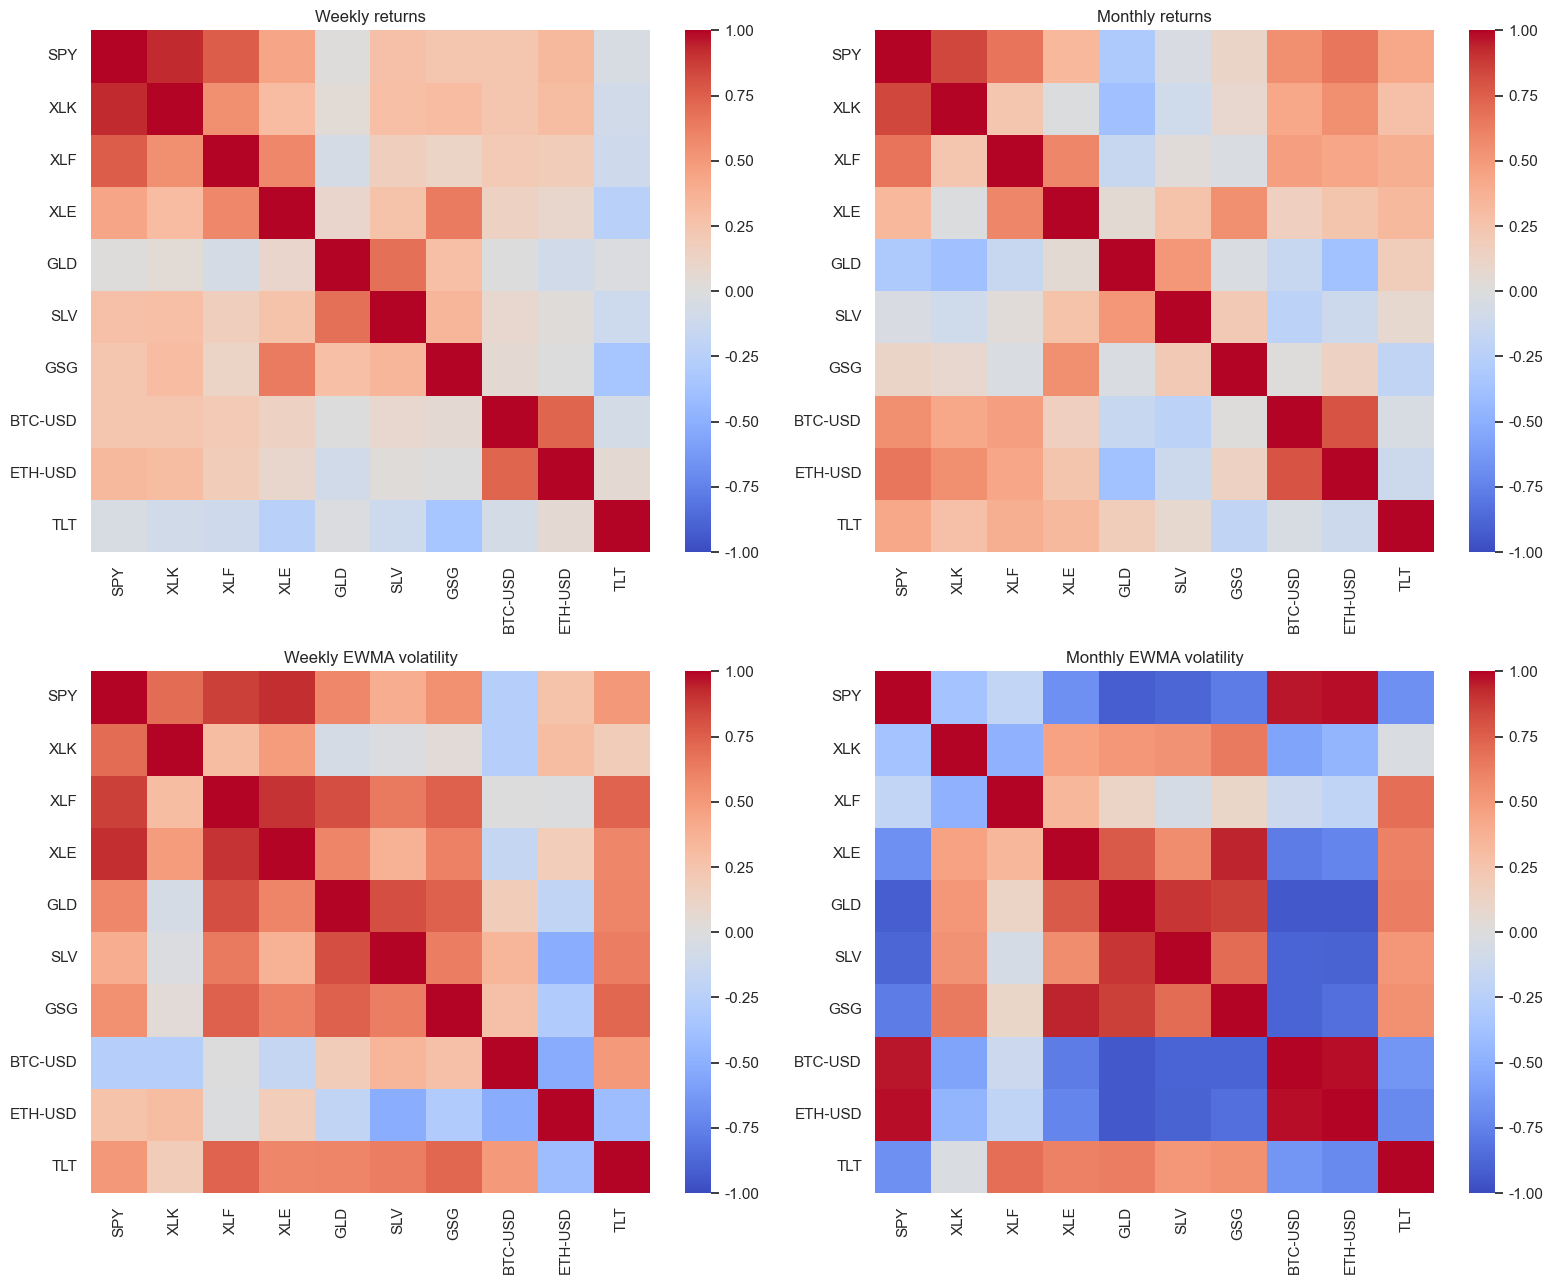

In [8]:
for label, result in q1_results.items():
    print(f"\nStrongest contemporaneous absolute correlations - {label}")
    print(tabulate(strongest_abs_correlations(result["panel"]).round(3), headers="keys", tablefmt="rounded_outline", showindex=False))

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
axes = axes.flatten()
for ax, (label, result) in zip(axes, q1_results.items()):
    sns.heatmap(result["panel"].corr(), cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title(label)
plt.tight_layout()
plt.show()



Network summary - Weekly returns
╭─────────┬──────────────┬─────────────╮
│ asset   │   out_degree │   in_degree │
├─────────┼──────────────┼─────────────┤
│ ETH-USD │            2 │           0 │
│ TLT     │            1 │           1 │
│ GSG     │            1 │           0 │
│ GLD     │            0 │           2 │
│ XLK     │            0 │           1 │
│ SPY     │            0 │           0 │
│ XLF     │            0 │           0 │
│ XLE     │            0 │           0 │
│ SLV     │            0 │           0 │
│ BTC-USD │            0 │           0 │
╰─────────┴──────────────┴─────────────╯


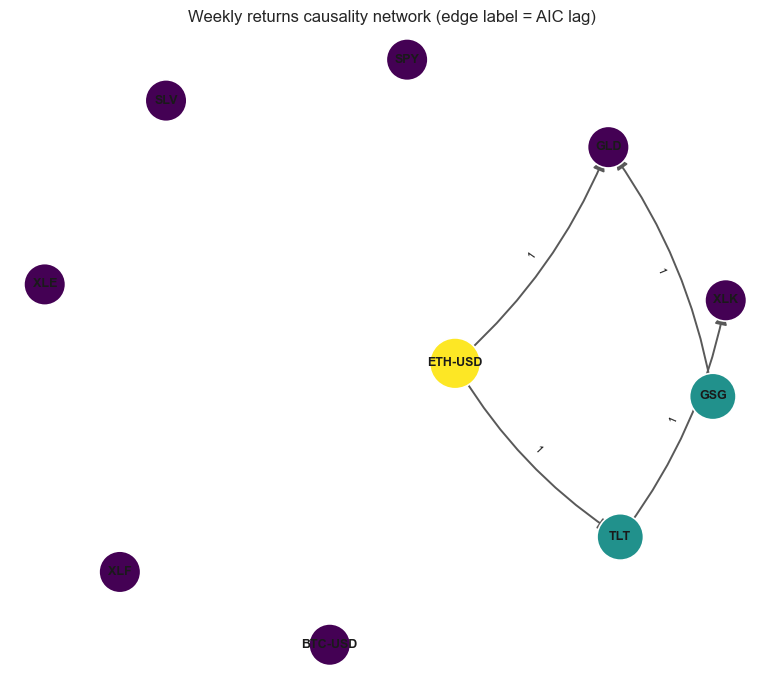


Network summary - Monthly returns
╭─────────┬──────────────┬─────────────╮
│ asset   │   out_degree │   in_degree │
├─────────┼──────────────┼─────────────┤
│ BTC-USD │            4 │           2 │
│ SPY     │            4 │           1 │
│ TLT     │            4 │           0 │
│ ETH-USD │            2 │           1 │
│ GSG     │            1 │           4 │
│ GLD     │            1 │           2 │
│ XLF     │            1 │           1 │
│ XLK     │            1 │           0 │
│ XLE     │            0 │           4 │
│ SLV     │            0 │           3 │
╰─────────┴──────────────┴─────────────╯


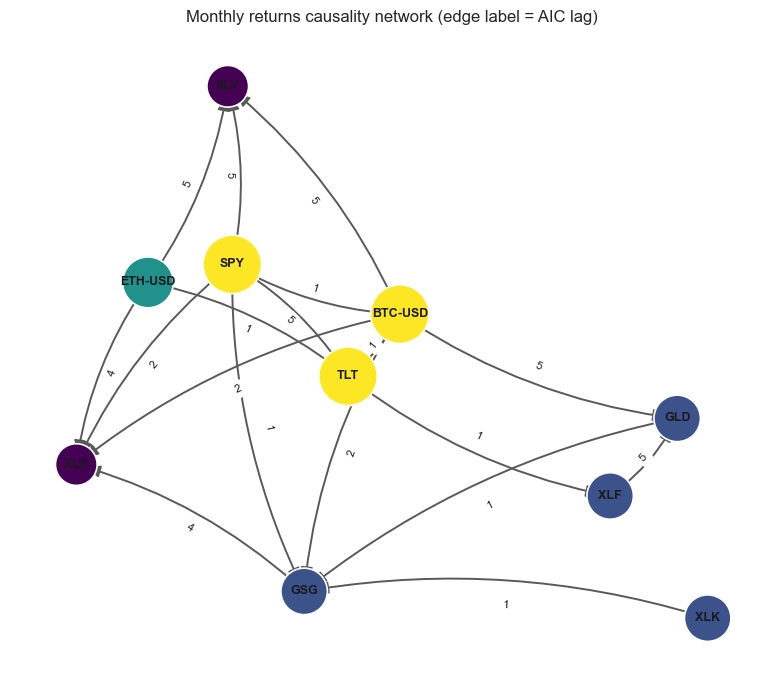


Network summary - Weekly EWMA volatility
╭─────────┬──────────────┬─────────────╮
│ asset   │   out_degree │   in_degree │
├─────────┼──────────────┼─────────────┤
│ XLF     │            5 │           0 │
│ SPY     │            4 │           1 │
│ XLE     │            4 │           0 │
│ XLK     │            3 │           0 │
│ GLD     │            1 │           5 │
│ GSG     │            1 │           4 │
│ BTC-USD │            1 │           4 │
│ SLV     │            1 │           0 │
│ TLT     │            0 │           6 │
│ ETH-USD │            0 │           0 │
╰─────────┴──────────────┴─────────────╯


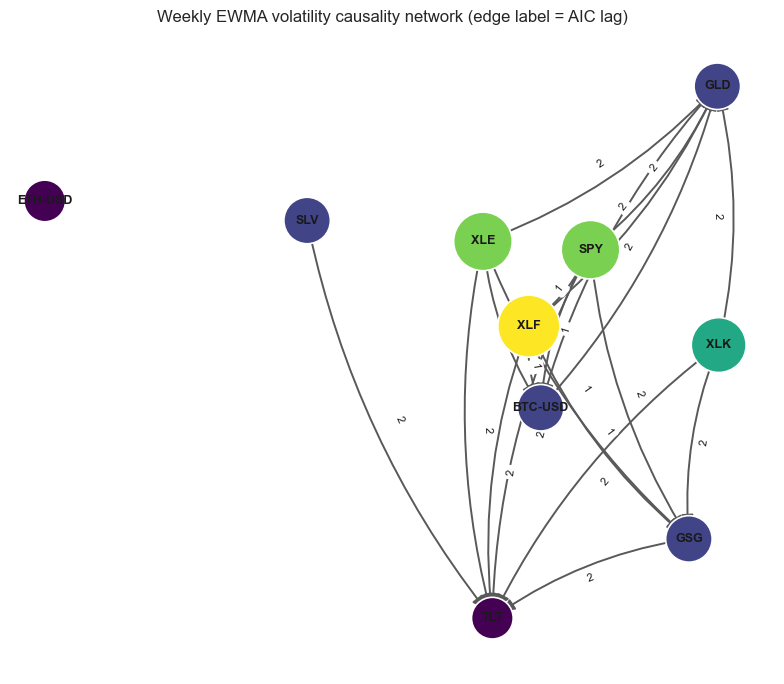


Network summary - Monthly EWMA volatility
╭─────────┬──────────────┬─────────────╮
│ asset   │   out_degree │   in_degree │
├─────────┼──────────────┼─────────────┤
│ SPY     │            3 │           2 │
│ XLK     │            3 │           1 │
│ TLT     │            3 │           1 │
│ XLE     │            2 │           2 │
│ BTC-USD │            2 │           0 │
│ XLF     │            1 │           2 │
│ SLV     │            1 │           0 │
│ GSG     │            0 │           4 │
│ GLD     │            0 │           2 │
│ ETH-USD │            0 │           1 │
╰─────────┴──────────────┴─────────────╯


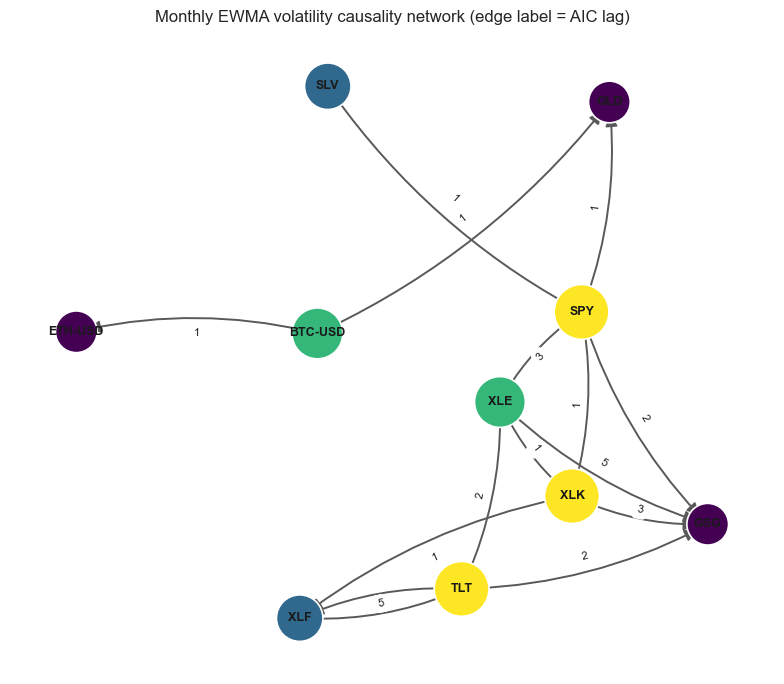

In [9]:
q1_graphs = {}
for label, result in q1_results.items():
    print(f"\nNetwork summary - {label}")
    summary = network_summary(result["lag_table"])
    print(tabulate(summary, headers="keys", tablefmt="rounded_outline", showindex=False))
    q1_graphs[label] = plot_causality_network(result["lag_table"], f"{label} causality network (edge label = AIC lag)")


### 1.3 Result Notes for the Report

After running the cells above, use the four causality tables and network summaries to write the report narrative:
- Returns network: assets with high out-degree are the main price-return drivers in this sample.
- Volatility network: assets with high out-degree are the main volatility or "fear" transmitters.
- Compare causal edges with the contemporaneous correlation lists; high same-period correlation is not the same as lagged Granger causality.
- Economic interpretation should be tied to the selected epoch. For example, crypto/technology links, commodity/energy links, or Treasury/equity links should be discussed only if they appear in the tables.


### 2.1 Data Preparation — Goyal-Welch Predictors

In [10]:
# ── Load ──────────────────────────────────────────────────────────────────────
GOYAL_CSV = '../GoyalMonthly2005.csv'   # one level up from Hw1/

gw_raw = pd.read_csv(GOYAL_CSV, parse_dates=['Date'])
gw_raw = gw_raw.rename(columns={'b/m': 'bm'})
print(f"Raw shape: {gw_raw.shape}  |  columns: {list(gw_raw.columns)}")
print(f"Raw date range: {gw_raw['Date'].min().date()} → {gw_raw['Date'].max().date()}")

# ── Filter to 1927-2021 (source file ends 2005, so upper bound has no effect) ─
gw = gw_raw[
    (gw_raw['Date'].dt.year >= 1927) &
    (gw_raw['Date'].dt.year <= 2021)
].copy().sort_values('Date').reset_index(drop=True)

actual_end = gw['Date'].max().date()
print(f"\nFiltered shape : {gw.shape}")
print(f"Actual date range after filter: {gw['Date'].min().date()} → {actual_end}")
if actual_end.year < 2021:
    print(f"  Note: source data ends {actual_end}; the 2021 upper bound is not binding.")

# ── Derived Features ──────────────────────────────────────────────────────────
gw['SP']  = np.log(gw['Index'])   - np.log(gw['Index'].shift(1))   # target: log return
gw['dp']  = np.log(gw['D12'])     - np.log(gw['Index'])             # dividend-price ratio
gw['ep']  = np.log(gw['E12'])     - np.log(gw['Index'])             # earnings-price ratio
gw['de']  = np.log(gw['D12'])     - np.log(gw['E12'])               # dividend-earnings ratio
gw['dy']  = np.log(gw['D12'])     - np.log(gw['Index'].shift(1))    # dividend yield
gw['dfy'] = gw['BAA'] - gw['AAA']                                    # default yield spread
# bm, svar, ntis, tbl are already present in the raw data

ASSIGNED_FEATURES = ['ep', 'svar', 'ntis']           # assigned predictors
ALL_FEATURES      = ['ep', 'svar', 'ntis',
                     'dp', 'de', 'dy', 'dfy', 'bm', 'tbl']
TARGET = 'SP'

# ── Model dataframe (keep only rows where target is non-NaN) ─────────────────
gw_model = gw[['Date', TARGET] + ALL_FEATURES].dropna(subset=[TARGET]).copy()
print(f"\nModel dataframe: {gw_model.shape}   "
      f"({gw_model['Date'].min().date()} → {gw_model['Date'].max().date()})")

# ── Missing value report ──────────────────────────────────────────────────────
print("\n--- Missing values in model dataframe ---")
miss = gw_model[[TARGET] + ALL_FEATURES].isnull().sum()
pct  = (miss / len(gw_model) * 100).round(2)
print(tabulate(pd.DataFrame({"Missing": miss, "Pct %": pct}),
               headers="keys", tablefmt="rounded_outline"))

# ── Summary statistics ────────────────────────────────────────────────────────
print("\n--- Summary Statistics ---")
print(tabulate(
    gw_model[[TARGET] + ALL_FEATURES].describe().round(4),
    headers="keys", tablefmt="rounded_outline"
))


Raw shape: (1620, 18)  |  columns: ['Date', 'Index', 'D12', 'E12', 'bm', 'tbl', 'AAA', 'BAA', 'lty', 'ntis', 'Rfree', 'infl', 'ltr', 'corpr', 'svar', 'csp', 'CRSP_SPvw', 'CRSP_SPvwx']
Raw date range: 1871-01-01 → 2005-12-01

Filtered shape : (948, 18)
Actual date range after filter: 1927-01-01 → 2005-12-01
  Note: source data ends 2005-12-01; the 2021 upper bound is not binding.

Model dataframe: (947, 11)   (1927-02-01 → 2005-12-01)

--- Missing values in model dataframe ---
╭──────┬───────────┬─────────╮
│      │   Missing │   Pct % │
├──────┼───────────┼─────────┤
│ SP   │         0 │       0 │
│ ep   │         0 │       0 │
│ svar │         0 │       0 │
│ ntis │         0 │       0 │
│ dp   │         0 │       0 │
│ de   │         0 │       0 │
│ dy   │         0 │       0 │
│ dfy  │         0 │       0 │
│ bm   │         0 │       0 │
│ tbl  │         0 │       0 │
╰──────┴───────────┴─────────╯

--- Summary Statistics ---
╭───────┬──────────┬──────────┬──────────┬──────────┬────

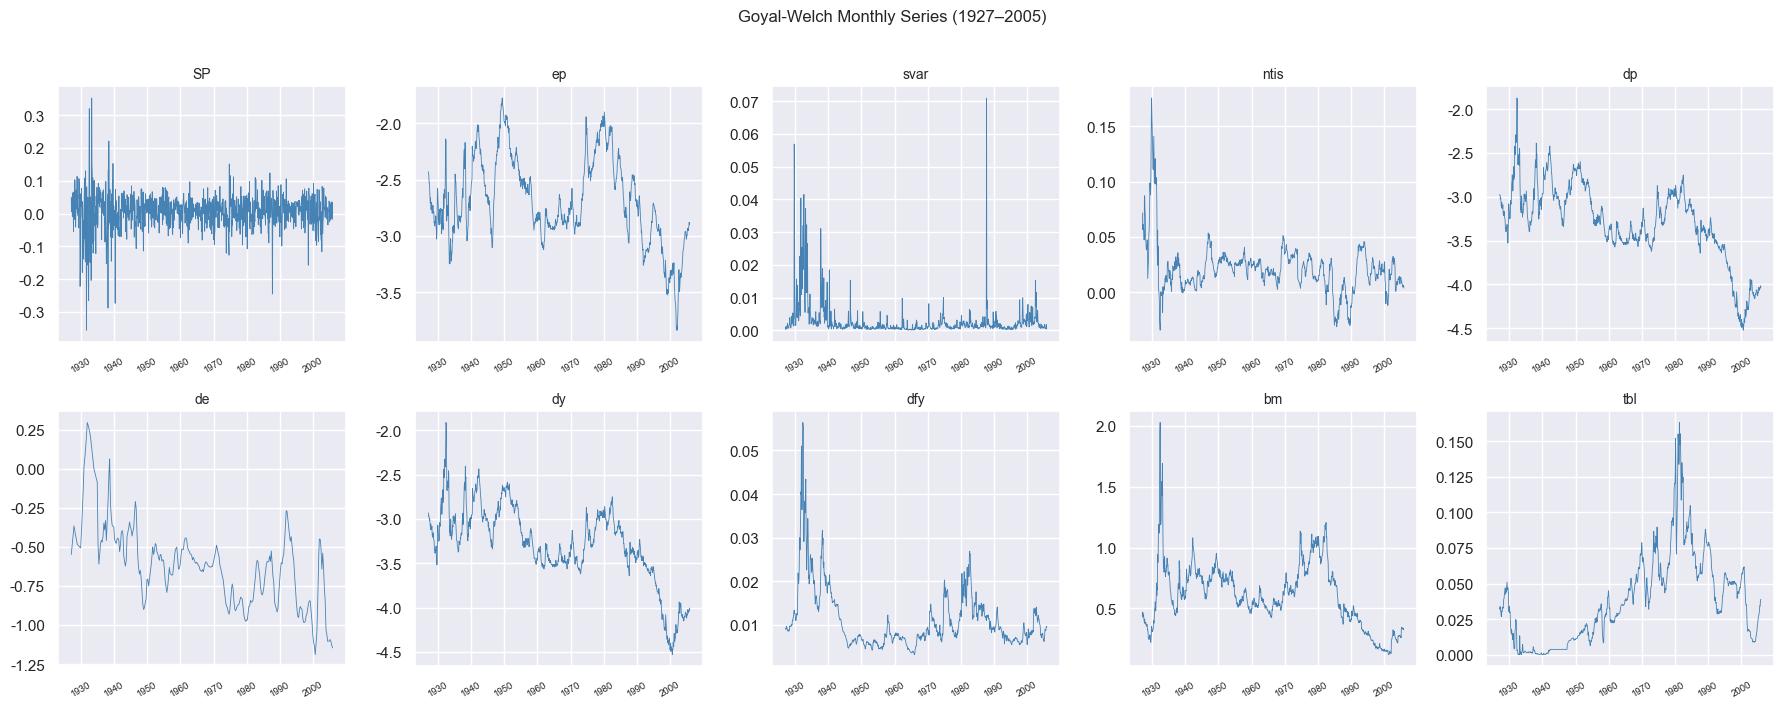

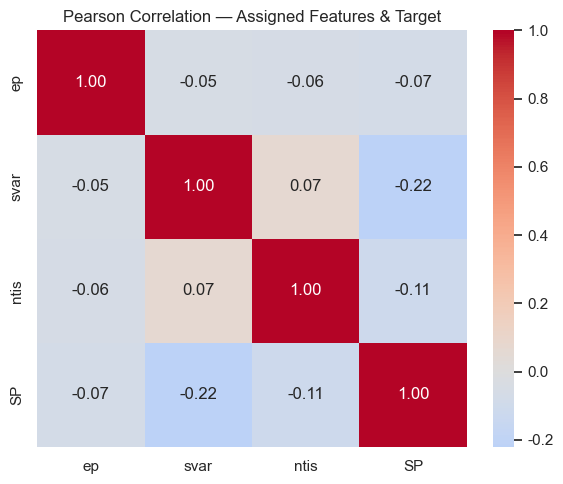

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

cols_to_plot = [TARGET] + ALL_FEATURES
for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    ax.plot(gw_model['Date'], gw_model[col], lw=0.6, color='steelblue')
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=7)

# hide any unused axes
for j in range(len(cols_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Goyal-Welch Monthly Series (1927–2005)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Correlation heatmap of assigned features vs target
subset = gw_model[ASSIGNED_FEATURES + [TARGET]].dropna()
fig2, ax2 = plt.subplots(figsize=(6, 5))
sns.heatmap(subset.corr().round(2), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax2)
ax2.set_title('Pearson Correlation — Assigned Features & Target')
plt.tight_layout()
plt.show()


---
### 2.2 – 2.x  Model Training & Evaluation (to be implemented)

*Exercise cells for MLP, LSTM, GP training, walk-forward backtesting,*
*and out-of-sample performance comparison will go here.*


In [35]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.gaussian_process.kernels import (
    RBF,
    Matern,
    RationalQuadratic,
    ExpSineSquared,
    DotProduct,
    WhiteKernel
)
from tensorflow.keras.callbacks import EarlyStopping

In [13]:
from sklearn.metrics import mean_squared_error

def nrmse(y_actual, y_predicted):
  return np.sqrt(mean_squared_error(y_actual, y_predicted)/np.mean(np.sum((y_actual-np.mean(y_actual))**2)))
## np.mean(y_actual.shift(1).dropna())
##Note: function mean_squared_error takes both arguments as arrays, so fails when given (array, mean (a number)), so must write this from scratch

def pcorrect(y_actual, y_predicted):
  return (1-nrmse(y_actual, y_predicted))*100

In [14]:
def creating_and_splitting(features,target):
    
    # Model Inputs:

    feat = gw[features+[target]]
    
    feat.columns = features + ['TARGET']
    feat.index = pd.DatetimeIndex(gw['Date'])
    feat = feat.dropna()

    target = 'TARGET'

    predictors = features   # <-- replace with your variables

    lags = [1,2, 3, 10,15]

    split_date = '2010-01-01'


    # CREATE LAGS


    for lag in lags:

        feat[f'{target}_lag{lag}'] = feat[target].shift(lag)

    for var in predictors:

        for lag in lags:

            feat[f'{var}_lag{lag}'] = feat[var].shift(lag)


    feat = feat.dropna()
    feat = feat.drop(columns=features)

    # Divide data into training (75%) and testing (25%).
    
    T = len(feat)
    p = 0.75
    trainindex = round(p*T)

    # process class sets as data frames
    training = feat.iloc[:trainindex, :]
    testing = feat.iloc[trainindex:, :]

    training_features = training.drop(columns='TARGET')
    training_target = training['TARGET']

    testing_features = testing.drop(columns='TARGET')
    testing_target = testing['TARGET']


    # DISTANCE CORRELATION

    distance_corrs = {}

    for col in training_features.columns:

        corr = dcor.distance_correlation(
            training_features[col].values,
            training_target.values
        )

        distance_corrs[col] = corr

    distance_corrs = pd.DataFrame({

        'feature': distance_corrs.keys(),
        'distance_corr': distance_corrs.values()

    })

    distance_corrs = distance_corrs.sort_values(
        by='distance_corr',
        ascending=False
    )

    top_features = distance_corrs.head(15)['feature'].tolist()

    training_features = training_features[top_features]

    testing_features = testing_features[top_features]

    return training_features,training_target,testing_features,testing_target

In [15]:
def fit_and_predict(pipeline,train_feat,train_targ,test_feat):
    
    pipeline.fit(train_feat,train_targ)

    a = pd.Series(pipeline.predict(test_feat),index=test_feat.index)

    return a

VARIABLES ASSIGNED ARE: **ep** ,**svar** ,**ntis**

### Option 1. Target =  Price


#### Model 1 NNET

In [76]:
results_df = np.empty(shape=(2,4))

training_features,training_target,testing_features,testing_target = creating_and_splitting(['ep','svar','ntis'],'Index')

param_grid = {'mlp__hidden_layer_sizes': [(200,),(60,60),(30,30,30,30)],
    'mlp__activation': ['relu','identity'],          
    'mlp__alpha': [0.001, 0.1]}

tscv = TimeSeriesSplit(n_splits=5)

search = GridSearchCV(Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(max_iter=2000, early_stopping=True, random_state=42))]), 
        param_grid=param_grid, cv=tscv, scoring='neg_root_mean_squared_error')

search.fit(training_features,training_target)

best_nnet_pred_price = fit_and_predict(pipeline=search.best_estimator_,train_feat=training_features,train_targ=training_target,test_feat=testing_features)

results_df[0,0] = nrmse(y_actual=testing_target,y_predicted=best_nnet_pred_price)
results_df[1,0] = pcorrect(y_actual=testing_target,y_predicted=best_nnet_pred_price)
# sensitivity exogenous variables

configurations = [['ep','svar'],['ep','ntis'],['svar','ntis']]

for i in range(3): 

    training_features,training_target,testing_features,testing_target = creating_and_splitting(configurations[i],'Index')

    nnet1_pred = fit_and_predict(pipeline=search.best_estimator_,train_feat=training_features,train_targ=training_target,test_feat=testing_features)

    results_df[0,i+1] = nrmse(y_actual=testing_target,y_predicted=nnet1_pred)
    results_df[1,i+1] = pcorrect(y_actual=testing_target,y_predicted=nnet1_pred)


print('Results \n')
display(pd.DataFrame(results_df,index=['nrmse','p_correct']))


print('Best params for the full model \n')
print(search.best_params_)


Results 



,0,1,2,3
nrmse,0.007457,0.007726,0.008373,0.007457
p_correct,99.254257,99.227434,99.162652,99.254257


Best params for the full model 

{'mlp__activation': 'identity', 'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (30, 30, 30, 30)}


#### Model 2 GP

In [77]:
results_df = np.empty(shape=(2,4))

training_features,training_target,testing_features,testing_target = creating_and_splitting(['ep','svar','ntis'],'Index')

param_grid = {'gp__kernel': [RBF(), Matern(nu=1.5), RationalQuadratic(), RBF() + WhiteKernel(0.1)]}
tscv = TimeSeriesSplit(n_splits=5)

search = GridSearchCV(Pipeline([
        ('scaler', StandardScaler()),
        ('gp', GaussianProcessRegressor(alpha=0.003))]), 
        param_grid=param_grid, cv=tscv, scoring='neg_root_mean_squared_error')

search.fit(training_features,training_target)

best_nnet_pred_price = fit_and_predict(pipeline=search.best_estimator_,train_feat=training_features,train_targ=training_target,test_feat=testing_features)

results_df[0,0] = nrmse(y_actual=testing_target,y_predicted=best_nnet_pred_price)
results_df[1,0] = pcorrect(y_actual=testing_target,y_predicted=best_nnet_pred_price)
# sensitivity exogenous variables

configurations = [['ep','svar'],['ep','ntis'],['svar','ntis']]

for i in range(3): 

    training_features,training_target,testing_features,testing_target = creating_and_splitting(configurations[i],'Index')

    nnet1_pred = fit_and_predict(pipeline=search.best_estimator_,train_feat=training_features,train_targ=training_target,test_feat=testing_features)

    results_df[0,i+1] = nrmse(y_actual=testing_target,y_predicted=nnet1_pred)
    results_df[1,i+1] = pcorrect(y_actual=testing_target,y_predicted=nnet1_pred)


print('Results \n')
display(pd.DataFrame(results_df,index=['nrmse','p_correct']))


print('Best params for the full model \n')
print(search.best_params_)

Results 



,0,1,2,3
nrmse,0.135562,0.135736,0.134836,0.135562
p_correct,86.443773,86.426388,86.516372,86.443773


Best params for the full model 

{'gp__kernel': RationalQuadratic(alpha=1, length_scale=1)}


#### Model 3 LSTM

In [78]:
training_features,training_target,testing_features,testing_target = creating_and_splitting(['ep','svar','ntis'],'Index')

lstm_results = np.empty(shape=(2,4))
scaler_X = StandardScaler()
scaler_y = StandardScaler()

training_features_scaled = scaler_X.fit_transform(training_features)
testing_features_scaled = scaler_X.transform(testing_features)

training_target_scaled = scaler_y.fit_transform(
    training_target.values.reshape(-1,1)
)
# Reshape the features for LSTM input
# LSTM expects input in the shape (samples, timesteps, features)
timesteps = 10  # Number of past time steps to consider, so target is 11
num_features = training_features.shape[1]  # Number of features (excluding target)
X_train = np.empty(shape=(training_features.shape[0]-timesteps,timesteps,num_features))
y_train = np.empty(shape=(training_target.shape[0]-timesteps,1))
for i in range(timesteps, training_features.shape[0]):
    X_train[i-timesteps,:,:]=training_features.iloc[i - timesteps:i, :]  
    y_train[i-timesteps,0]=training_target.iloc[i]  

# Define the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], num_features)))
model.add(LSTM(units=50))
model.add(Dense(1))

# Compile the model
model.compile(loss='mean_squared_error', optimizer='adam')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
model.fit(X_train,y_train,epochs=100,batch_size=32,validation_split=0.1,callbacks=[early_stop],verbose=0)

# Prepare testing data
X_test = np.empty(shape=(testing_features.shape[0]-timesteps,timesteps,num_features))
for i in range(timesteps, testing_features.shape[0]):
    X_test[i-timesteps,:,:]=testing_features.iloc[i - timesteps:i, :]


# Make predictions
pred_lstm_price_1 = scaler_y.inverse_transform(model.predict(X_test))


lstm_results[0,0] = nrmse(y_actual=testing_target.iloc[timesteps:],y_predicted=pred_lstm_price_1)
lstm_results[1,0] = pcorrect(y_actual=testing_target.iloc[timesteps:],y_predicted=pred_lstm_price_1)


# Reshape the features for LSTM input
# LSTM expects input in the shape (samples, timesteps, features)
timesteps = 10  # Number of past time steps to consider, so target is 11
num_features = training_features.shape[1]  # Number of features (excluding target)
X_train = np.empty(shape=(training_features.shape[0]-timesteps,timesteps,num_features))
y_train = np.empty(shape=(training_target.shape[0]-timesteps,1))
for i in range(timesteps, training_features.shape[0]):
    X_train[i-timesteps,:,:]=training_features.iloc[i - timesteps:i, :]  
    y_train[i-timesteps,0]=training_target.iloc[i]  

# Define the LSTM model
model = Sequential()
model.add(LSTM(units=10, return_sequences=True, input_shape=(X_train.shape[1], num_features)))
model.add(LSTM(units=10))
model.add(Dense(1))

# Compile the model
model.compile(loss='mean_squared_error', optimizer='adam')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
model.fit(X_train,y_train,epochs=100,batch_size=32,validation_split=0.1,callbacks=[early_stop],verbose=0)

# Prepare testing data
X_test = np.empty(shape=(testing_features.shape[0]-timesteps,timesteps,num_features))
for i in range(timesteps, testing_features.shape[0]):
    X_test[i-timesteps,:,:]=testing_features.iloc[i - timesteps:i, :]


# Make predictions
pred_lstm_price_2 = scaler_y.inverse_transform(model.predict(X_test))

lstm_results[0,1] = nrmse(y_actual=testing_target.iloc[timesteps:],y_predicted=pred_lstm_price_2)
lstm_results[1,1] = pcorrect(y_actual=testing_target.iloc[timesteps:],y_predicted=pred_lstm_price_2)


# Reshape the features for LSTM input
# LSTM expects input in the shape (samples, timesteps, features)
timesteps = 5  # Number of past time steps to consider, so target is 11
num_features = training_features.shape[1]  # Number of features (excluding target)
X_train = np.empty(shape=(training_features.shape[0]-timesteps,timesteps,num_features))
y_train = np.empty(shape=(training_target.shape[0]-timesteps,1))
for i in range(timesteps, training_features.shape[0]):
    X_train[i-timesteps,:,:]=training_features.iloc[i - timesteps:i, :]  
    y_train[i-timesteps,0]=training_target.iloc[i]  

# Define the LSTM model
model = Sequential()
model.add(LSTM(units=10, return_sequences=True, input_shape=(X_train.shape[1], num_features)))
model.add(LSTM(units=10))
model.add(Dense(1))

# Compile the model
model.compile(loss='mean_squared_error', optimizer='adam')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
model.fit(X_train,y_train,epochs=100,batch_size=32,validation_split=0.1,callbacks=[early_stop],verbose=0)

# Prepare testing data
X_test = np.empty(shape=(testing_features.shape[0]-timesteps,timesteps,num_features))
for i in range(timesteps, testing_features.shape[0]):
    X_test[i-timesteps,:,:]=testing_features.iloc[i - timesteps:i, :]


# Make predictions
pred_lstm_price_3 = scaler_y.inverse_transform(model.predict(X_test))

lstm_results[0,2] = nrmse(y_actual=testing_target.iloc[timesteps:],y_predicted=pred_lstm_price_3)
lstm_results[1,2] = pcorrect(y_actual=testing_target.iloc[timesteps:],y_predicted=pred_lstm_price_3)


# Reshape the features for LSTM input
# LSTM expects input in the shape (samples, timesteps, features)
timesteps = 10  # Number of past time steps to consider, so target is 11
num_features = training_features.shape[1]  # Number of features (excluding target)
X_train = np.empty(shape=(training_features.shape[0]-timesteps,timesteps,num_features))
y_train = np.empty(shape=(training_target.shape[0]-timesteps,1))
for i in range(timesteps, training_features.shape[0]):
    X_train[i-timesteps,:,:]=training_features.iloc[i - timesteps:i, :]  
    y_train[i-timesteps,0]=training_target.iloc[i]  

# Define the LSTM model
model = Sequential()
model.add(LSTM(units=10, input_shape=(X_train.shape[1], num_features)))
model.add(Dense(1))

# Compile the model
model.compile(loss='mean_squared_error', optimizer='adam')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
model.fit(X_train,y_train,epochs=100,batch_size=32,validation_split=0.1,callbacks=[early_stop],verbose=0)

# Prepare testing data
X_test = np.empty(shape=(testing_features.shape[0]-timesteps,timesteps,num_features))
for i in range(timesteps, testing_features.shape[0]):
    X_test[i-timesteps,:,:]=testing_features.iloc[i - timesteps:i, :]


# Make predictions
pred_lstm_price_4 = scaler_y.inverse_transform(model.predict(X_test))

lstm_results[0,3] = nrmse(y_actual=testing_target.iloc[timesteps:],y_predicted=pred_lstm_price_4)
lstm_results[1,3] = pcorrect(y_actual=testing_target.iloc[timesteps:],y_predicted=pred_lstm_price_4)


display(pd.DataFrame(lstm_results,index=['nrmse','pcorrect']))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


,0,1,2,3
nrmse,0.541307,0.112448,0.102570,0.109292
pcorrect,45.869264,88.755211,89.743003,89.070765


### Target 2 Returns

#### Model 1 NNET

In [81]:
results_df = np.empty(shape=(2,4))

training_features,training_target,testing_features,testing_target = creating_and_splitting(['ep','svar','ntis'],'SP')

param_grid = {'mlp__hidden_layer_sizes': [(50,),(200,),(60,60),(30,30,30,30)],
    'mlp__activation': ['relu','identity','tanh'],          
    'mlp__alpha': [0.001, 0.1]}

tscv = TimeSeriesSplit(n_splits=5)

search = GridSearchCV(Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(max_iter=2000, early_stopping=True, random_state=42))]), 
        param_grid=param_grid, cv=tscv, scoring='neg_root_mean_squared_error')

search.fit(training_features,training_target)

best_nnet_pred_price = fit_and_predict(pipeline=search.best_estimator_,train_feat=training_features,train_targ=training_target,test_feat=testing_features)

results_df[0,0] = nrmse(y_actual=testing_target,y_predicted=best_nnet_pred_price)
results_df[1,0] = pcorrect(y_actual=testing_target,y_predicted=best_nnet_pred_price)
# sensitivity exogenous variables

configurations = [['ep','svar'],['ep','ntis'],['svar','ntis']]

for i in range(3): 

    training_features,training_target,testing_features,testing_target = creating_and_splitting(configurations[i],'Index')

    nnet1_pred = fit_and_predict(pipeline=search.best_estimator_,train_feat=training_features,train_targ=training_target,test_feat=testing_features)

    results_df[0,i+1] = nrmse(y_actual=testing_target,y_predicted=nnet1_pred)
    results_df[1,i+1] = pcorrect(y_actual=testing_target,y_predicted=nnet1_pred)


print('Results \n')
display(pd.DataFrame(results_df,index=['nrmse','p_correct']))


print('Best params for the full model \n')
print(search.best_params_)


Results 



,0,1,2,3
nrmse,0.075688,0.016693,0.01229,0.011324
p_correct,92.431208,98.330661,98.77098,98.867561


Best params for the full model 

{'mlp__activation': 'relu', 'mlp__alpha': 0.1, 'mlp__hidden_layer_sizes': (30, 30, 30, 30)}


#### Model 2 GP

In [82]:
results_df = np.empty(shape=(2,4))

training_features,training_target,testing_features,testing_target = creating_and_splitting(['ep','svar','ntis'],'SP')

param_grid = {'gp__kernel': [RBF(), Matern(nu=1.5), RationalQuadratic(), RBF() + WhiteKernel(0.1)]}
tscv = TimeSeriesSplit(n_splits=5)

search = GridSearchCV(Pipeline([
        ('scaler', StandardScaler()),
        ('gp', GaussianProcessRegressor(alpha=0.003))]), 
        param_grid=param_grid, cv=tscv, scoring='neg_root_mean_squared_error')

search.fit(training_features,training_target)

best_nnet_pred_price = fit_and_predict(pipeline=search.best_estimator_,train_feat=training_features,train_targ=training_target,test_feat=testing_features)

results_df[0,0] = nrmse(y_actual=testing_target,y_predicted=best_nnet_pred_price)
results_df[1,0] = pcorrect(y_actual=testing_target,y_predicted=best_nnet_pred_price)
# sensitivity exogenous variables

configurations = [['ep','svar'],['ep','ntis'],['svar','ntis']]

for i in range(3): 

    training_features,training_target,testing_features,testing_target = creating_and_splitting(configurations[i],'Index')

    nnet1_pred = fit_and_predict(pipeline=search.best_estimator_,train_feat=training_features,train_targ=training_target,test_feat=testing_features)

    results_df[0,i+1] = nrmse(y_actual=testing_target,y_predicted=nnet1_pred)
    results_df[1,i+1] = pcorrect(y_actual=testing_target,y_predicted=nnet1_pred)


print('Results \n')
display(pd.DataFrame(results_df,index=['nrmse','p_correct']))


print('Best params for the full model \n')
print(search.best_params_)

Results 



,0,1,2,3
nrmse,0.068320,0.139374,0.139374,0.139374
p_correct,93.168034,86.062601,86.062601,86.062601


Best params for the full model 

{'gp__kernel': RBF(length_scale=1) + WhiteKernel(noise_level=0.1)}


#### Model 3 LSTM

In [83]:
training_features,training_target,testing_features,testing_target = creating_and_splitting(['ep','svar','ntis'],'SP')

lstm_results = np.empty(shape=(2,4))
scaler_X = StandardScaler()
scaler_y = StandardScaler()

training_features_scaled = scaler_X.fit_transform(training_features)
testing_features_scaled = scaler_X.transform(testing_features)

training_target_scaled = scaler_y.fit_transform(
    training_target.values.reshape(-1,1)
)
# Reshape the features for LSTM input
# LSTM expects input in the shape (samples, timesteps, features)
timesteps = 10  # Number of past time steps to consider, so target is 11
num_features = training_features.shape[1]  # Number of features (excluding target)
X_train = np.empty(shape=(training_features.shape[0]-timesteps,timesteps,num_features))
y_train = np.empty(shape=(training_target.shape[0]-timesteps,1))
for i in range(timesteps, training_features.shape[0]):
    X_train[i-timesteps,:,:]=training_features.iloc[i - timesteps:i, :]  
    y_train[i-timesteps,0]=training_target.iloc[i]  

# Define the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], num_features)))
model.add(LSTM(units=50))
model.add(Dense(1))

# Compile the model
model.compile(loss='mean_squared_error', optimizer='adam')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
model.fit(X_train,y_train,epochs=100,batch_size=32,validation_split=0.1,callbacks=[early_stop],verbose=0)

# Prepare testing data
X_test = np.empty(shape=(testing_features.shape[0]-timesteps,timesteps,num_features))
for i in range(timesteps, testing_features.shape[0]):
    X_test[i-timesteps,:,:]=testing_features.iloc[i - timesteps:i, :]


# Make predictions
pred_lstm_price_1 = scaler_y.inverse_transform(model.predict(X_test))


lstm_results[0,0] = nrmse(y_actual=testing_target.iloc[timesteps:],y_predicted=pred_lstm_price_1)
lstm_results[1,0] = pcorrect(y_actual=testing_target.iloc[timesteps:],y_predicted=pred_lstm_price_1)


# Reshape the features for LSTM input
# LSTM expects input in the shape (samples, timesteps, features)
timesteps = 10  # Number of past time steps to consider, so target is 11
num_features = training_features.shape[1]  # Number of features (excluding target)
X_train = np.empty(shape=(training_features.shape[0]-timesteps,timesteps,num_features))
y_train = np.empty(shape=(training_target.shape[0]-timesteps,1))
for i in range(timesteps, training_features.shape[0]):
    X_train[i-timesteps,:,:]=training_features.iloc[i - timesteps:i, :]  
    y_train[i-timesteps,0]=training_target.iloc[i]  

# Define the LSTM model
model = Sequential()
model.add(LSTM(units=10, return_sequences=True, input_shape=(X_train.shape[1], num_features)))
model.add(LSTM(units=10))
model.add(Dense(1))

# Compile the model
model.compile(loss='mean_squared_error', optimizer='adam')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
model.fit(X_train,y_train,epochs=100,batch_size=32,validation_split=0.1,callbacks=[early_stop],verbose=0)

# Prepare testing data
X_test = np.empty(shape=(testing_features.shape[0]-timesteps,timesteps,num_features))
for i in range(timesteps, testing_features.shape[0]):
    X_test[i-timesteps,:,:]=testing_features.iloc[i - timesteps:i, :]


# Make predictions
pred_lstm_price_2 = scaler_y.inverse_transform(model.predict(X_test))

lstm_results[0,1] = nrmse(y_actual=testing_target.iloc[timesteps:],y_predicted=pred_lstm_price_2)
lstm_results[1,1] = pcorrect(y_actual=testing_target.iloc[timesteps:],y_predicted=pred_lstm_price_2)


# Reshape the features for LSTM input
# LSTM expects input in the shape (samples, timesteps, features)
timesteps = 5  # Number of past time steps to consider, so target is 11
num_features = training_features.shape[1]  # Number of features (excluding target)
X_train = np.empty(shape=(training_features.shape[0]-timesteps,timesteps,num_features))
y_train = np.empty(shape=(training_target.shape[0]-timesteps,1))
for i in range(timesteps, training_features.shape[0]):
    X_train[i-timesteps,:,:]=training_features.iloc[i - timesteps:i, :]  
    y_train[i-timesteps,0]=training_target.iloc[i]  

# Define the LSTM model
model = Sequential()
model.add(LSTM(units=10, return_sequences=True, input_shape=(X_train.shape[1], num_features)))
model.add(LSTM(units=10))
model.add(Dense(1))

# Compile the model
model.compile(loss='mean_squared_error', optimizer='adam')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
model.fit(X_train,y_train,epochs=100,batch_size=32,validation_split=0.1,callbacks=[early_stop],verbose=0)

# Prepare testing data
X_test = np.empty(shape=(testing_features.shape[0]-timesteps,timesteps,num_features))
for i in range(timesteps, testing_features.shape[0]):
    X_test[i-timesteps,:,:]=testing_features.iloc[i - timesteps:i, :]


# Make predictions
pred_lstm_price_3 = scaler_y.inverse_transform(model.predict(X_test))

lstm_results[0,2] = nrmse(y_actual=testing_target.iloc[timesteps:],y_predicted=pred_lstm_price_3)
lstm_results[1,2] = pcorrect(y_actual=testing_target.iloc[timesteps:],y_predicted=pred_lstm_price_3)


# Reshape the features for LSTM input
# LSTM expects input in the shape (samples, timesteps, features)
timesteps = 10  # Number of past time steps to consider, so target is 11
num_features = training_features.shape[1]  # Number of features (excluding target)
X_train = np.empty(shape=(training_features.shape[0]-timesteps,timesteps,num_features))
y_train = np.empty(shape=(training_target.shape[0]-timesteps,1))
for i in range(timesteps, training_features.shape[0]):
    X_train[i-timesteps,:,:]=training_features.iloc[i - timesteps:i, :]  
    y_train[i-timesteps,0]=training_target.iloc[i]  

# Define the LSTM model
model = Sequential()
model.add(LSTM(units=10, input_shape=(X_train.shape[1], num_features)))
model.add(Dense(1))

# Compile the model
model.compile(loss='mean_squared_error', optimizer='adam')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
model.fit(X_train,y_train,epochs=100,batch_size=32,validation_split=0.1,callbacks=[early_stop],verbose=0)

# Prepare testing data
X_test = np.empty(shape=(testing_features.shape[0]-timesteps,timesteps,num_features))
for i in range(timesteps, testing_features.shape[0]):
    X_test[i-timesteps,:,:]=testing_features.iloc[i - timesteps:i, :]


# Make predictions
pred_lstm_price_4 = scaler_y.inverse_transform(model.predict(X_test))

lstm_results[0,3] = nrmse(y_actual=testing_target.iloc[timesteps:],y_predicted=pred_lstm_price_4)
lstm_results[1,3] = pcorrect(y_actual=testing_target.iloc[timesteps:],y_predicted=pred_lstm_price_4)


display(pd.DataFrame(lstm_results,index=['nrmse','pcorrect']))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


,0,1,2,3
nrmse,0.067041,0.067082,0.066444,0.067156
pcorrect,93.295933,93.291839,93.355648,93.284377


### TARGET 3 Direction

In [84]:
gw['direction'] = (gw['SP']>0).astype(int)

#### Model 1 NNET

In [85]:
results_df = np.empty(shape=(2,4))

training_features,training_target,testing_features,testing_target = creating_and_splitting(['ep','svar','ntis'],'direction')

param_grid = {'mlp__hidden_layer_sizes': [(200,),(60,60),(30,30,30,30)],
    'mlp__activation': ['relu','identity','tanh'],          
    'mlp__alpha': [0.001, 0.1]}

tscv = TimeSeriesSplit(n_splits=5)

search = GridSearchCV(Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(max_iter=2000, early_stopping=True, random_state=42))]), 
        param_grid=param_grid, cv=tscv, scoring='neg_root_mean_squared_error')

search.fit(training_features,training_target)

best_nnet_pred_price = fit_and_predict(pipeline=search.best_estimator_,train_feat=training_features,train_targ=training_target,test_feat=testing_features)

results_df[0,0] = nrmse(y_actual=testing_target,y_predicted=best_nnet_pred_price)
results_df[1,0] = pcorrect(y_actual=testing_target,y_predicted=best_nnet_pred_price)
# sensitivity exogenous variables

configurations = [['ep','svar'],['ep','ntis'],['svar','ntis']]

for i in range(3): 

    training_features,training_target,testing_features,testing_target = creating_and_splitting(configurations[i],'Index')

    nnet1_pred = fit_and_predict(pipeline=search.best_estimator_,train_feat=training_features,train_targ=training_target,test_feat=testing_features)

    results_df[0,i+1] = nrmse(y_actual=testing_target,y_predicted=nnet1_pred)
    results_df[1,i+1] = pcorrect(y_actual=testing_target,y_predicted=nnet1_pred)


print('Results \n')
display(pd.DataFrame(results_df,index=['nrmse','p_correct']))


print('Best params for the full model \n')
print(search.best_params_)


Results 



,0,1,2,3
nrmse,0.067144,0.119965,0.119532,0.119049
p_correct,93.285577,88.003455,88.046794,88.095093


Best params for the full model 

{'mlp__activation': 'tanh', 'mlp__alpha': 0.1, 'mlp__hidden_layer_sizes': (30, 30, 30, 30)}


#### Model 2 GP

In [86]:
results_df = np.empty(shape=(2,4))

training_features,training_target,testing_features,testing_target = creating_and_splitting(['ep','svar','ntis'],'direction')

param_grid = {'gp__kernel': [RBF(), Matern(nu=1.5), RationalQuadratic(), RBF() + WhiteKernel(0.1)]}
tscv = TimeSeriesSplit(n_splits=5)

search = GridSearchCV(Pipeline([
        ('scaler', StandardScaler()),
        ('gp', GaussianProcessRegressor(alpha=0.003))]), 
        param_grid=param_grid, cv=tscv, scoring='neg_root_mean_squared_error')

search.fit(training_features,training_target)

best_nnet_pred_price = fit_and_predict(pipeline=search.best_estimator_,train_feat=training_features,train_targ=training_target,test_feat=testing_features)

results_df[0,0] = nrmse(y_actual=testing_target,y_predicted=best_nnet_pred_price)
results_df[1,0] = pcorrect(y_actual=testing_target,y_predicted=best_nnet_pred_price)
# sensitivity exogenous variables

configurations = [['ep','svar'],['ep','ntis'],['svar','ntis']]

for i in range(3): 

    training_features,training_target,testing_features,testing_target = creating_and_splitting(configurations[i],'Index')

    nnet1_pred = fit_and_predict(pipeline=search.best_estimator_,train_feat=training_features,train_targ=training_target,test_feat=testing_features)

    results_df[0,i+1] = nrmse(y_actual=testing_target,y_predicted=nnet1_pred)
    results_df[1,i+1] = pcorrect(y_actual=testing_target,y_predicted=nnet1_pred)


print('Results \n')
display(pd.DataFrame(results_df,index=['nrmse','p_correct']))


print('Best params for the full model \n')
print(search.best_params_)

Results 



,0,1,2,3
nrmse,0.066513,0.135736,0.134836,0.135562
p_correct,93.348715,86.426388,86.516372,86.443773


Best params for the full model 

{'gp__kernel': RationalQuadratic(alpha=1, length_scale=1)}


#### Model 3 LSTM

In [91]:
training_features,training_target,testing_features,testing_target = creating_and_splitting(['ep','svar','ntis'],'direction')

lstm_results = np.empty(shape=(2,4))
scaler_X = StandardScaler()


training_features_scaled = scaler_X.fit_transform(training_features)
testing_features_scaled = scaler_X.transform(testing_features)

training_target_scaled = scaler_y.fit_transform(
    training_target.values.reshape(-1,1)
)

# Reshape the features for LSTM input
# LSTM expects input in the shape (samples, timesteps, features)
timesteps = 10  # Number of past time steps to consider, so target is 11
num_features = training_features.shape[1]  # Number of features (excluding target)
X_train = np.empty(shape=(training_features.shape[0]-timesteps,timesteps,num_features))
y_train = np.empty(shape=(training_target.shape[0]-timesteps,1))
for i in range(timesteps, training_features.shape[0]):
    X_train[i-timesteps,:,:]=training_features.iloc[i - timesteps:i, :]  
    y_train[i-timesteps,0]=training_target.iloc[i]  

# Define the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], num_features)))
model.add(LSTM(units=50))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
model.fit(X_train,y_train,epochs=100,batch_size=32,validation_split=0.1,callbacks=[early_stop],verbose=0)

# Prepare testing data
X_test = np.empty(shape=(testing_features.shape[0]-timesteps,timesteps,num_features))
for i in range(timesteps, testing_features.shape[0]):
    X_test[i-timesteps,:,:]=testing_features.iloc[i - timesteps:i, :]


# Make predictions
pred_lstm_price_1 = model.predict(X_test)


lstm_results[0,0] = nrmse(y_actual=testing_target.iloc[timesteps:],y_predicted=pred_lstm_price_1)
lstm_results[1,0] = pcorrect(y_actual=testing_target.iloc[timesteps:],y_predicted=pred_lstm_price_1)


# Reshape the features for LSTM input
# LSTM expects input in the shape (samples, timesteps, features)
timesteps = 10  # Number of past time steps to consider, so target is 11
num_features = training_features.shape[1]  # Number of features (excluding target)
X_train = np.empty(shape=(training_features.shape[0]-timesteps,timesteps,num_features))
y_train = np.empty(shape=(training_target.shape[0]-timesteps,1))
for i in range(timesteps, training_features.shape[0]):
    X_train[i-timesteps,:,:]=training_features.iloc[i - timesteps:i, :]  
    y_train[i-timesteps,0]=training_target.iloc[i]  

# Define the LSTM model
model = Sequential()
model.add(LSTM(units=10, return_sequences=True, input_shape=(X_train.shape[1], num_features)))
model.add(LSTM(units=10))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
model.fit(X_train,y_train,epochs=100,batch_size=32,validation_split=0.1,callbacks=[early_stop],verbose=0)

# Prepare testing data
X_test = np.empty(shape=(testing_features.shape[0]-timesteps,timesteps,num_features))
for i in range(timesteps, testing_features.shape[0]):
    X_test[i-timesteps,:,:]=testing_features.iloc[i - timesteps:i, :]


# Make predictions
pred_lstm_price_2 = model.predict(X_test)

lstm_results[0,1] = nrmse(y_actual=testing_target.iloc[timesteps:],y_predicted=pred_lstm_price_2)
lstm_results[1,1] = pcorrect(y_actual=testing_target.iloc[timesteps:],y_predicted=pred_lstm_price_2)


# Reshape the features for LSTM input
# LSTM expects input in the shape (samples, timesteps, features)
timesteps = 5  # Number of past time steps to consider, so target is 11
num_features = training_features.shape[1]  # Number of features (excluding target)
X_train = np.empty(shape=(training_features.shape[0]-timesteps,timesteps,num_features))
y_train = np.empty(shape=(training_target.shape[0]-timesteps,1))
for i in range(timesteps, training_features.shape[0]):
    X_train[i-timesteps,:,:]=training_features.iloc[i - timesteps:i, :]  
    y_train[i-timesteps,0]=training_target.iloc[i]  

# Define the LSTM model
model = Sequential()
model.add(LSTM(units=10, return_sequences=True, input_shape=(X_train.shape[1], num_features)))
model.add(LSTM(units=10))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
model.fit(X_train,y_train,epochs=100,batch_size=32,validation_split=0.1,callbacks=[early_stop],verbose=0)

# Prepare testing data
X_test = np.empty(shape=(testing_features.shape[0]-timesteps,timesteps,num_features))
for i in range(timesteps, testing_features.shape[0]):
    X_test[i-timesteps,:,:]=testing_features.iloc[i - timesteps:i, :]


# Make predictions
pred_lstm_price_3 = model.predict(X_test)

lstm_results[0,2] = nrmse(y_actual=testing_target.iloc[timesteps:],y_predicted=pred_lstm_price_3)
lstm_results[1,2] = pcorrect(y_actual=testing_target.iloc[timesteps:],y_predicted=pred_lstm_price_3)


# Reshape the features for LSTM input
# LSTM expects input in the shape (samples, timesteps, features)
timesteps = 10  # Number of past time steps to consider, so target is 11
num_features = training_features.shape[1]  # Number of features (excluding target)
X_train = np.empty(shape=(training_features.shape[0]-timesteps,timesteps,num_features))
y_train = np.empty(shape=(training_target.shape[0]-timesteps,1))
for i in range(timesteps, training_features.shape[0]):
    X_train[i-timesteps,:,:]=training_features.iloc[i - timesteps:i, :]  
    y_train[i-timesteps,0]=training_target.iloc[i]  

# Define the LSTM model
model = Sequential()
model.add(LSTM(units=10, input_shape=(X_train.shape[1], num_features)))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
model.fit(X_train,y_train,epochs=100,batch_size=32,validation_split=0.1,callbacks=[early_stop],verbose=0)

# Prepare testing data
X_test = np.empty(shape=(testing_features.shape[0]-timesteps,timesteps,num_features))
for i in range(timesteps, testing_features.shape[0]):
    X_test[i-timesteps,:,:]=testing_features.iloc[i - timesteps:i, :]


# Make predictions
pred_lstm_price_4 = model.predict(X_test)

lstm_results[0,3] = nrmse(y_actual=testing_target.iloc[timesteps:],y_predicted=pred_lstm_price_4)
lstm_results[1,3] = pcorrect(y_actual=testing_target.iloc[timesteps:],y_predicted=pred_lstm_price_4)


display(pd.DataFrame(lstm_results,index=['nrmse','pcorrect']))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


,0,1,2,3
nrmse,0.068799,0.067655,0.068391,0.067684
pcorrect,93.120086,93.234492,93.160906,93.231640


---
## 3. Problem 3: ARMA-GARCH Baseline (20%)

**Objective:** Fit an ARMA-GARCH model on the same `SP` log-return series as a
classical time-series benchmark.  Compare volatility forecasts and return forecasts
against the ML models from Problem 2.

*Uses the `gw_model` dataframe prepared in Section 2.1.*


---
### 3.1 – 3.x  ARMA-GARCH Implementation (to be implemented)

*Exercise cells for ADF testing, ARMA order selection, GARCH fitting,*
*volatility forecasting, and performance benchmarking will go here.*


---
## 4. Lessons Learned (5%)

*[To be filled in after completing all exercises.]*

Consider addressing:
- What causal relationships were most surprising in the asset network?
- How did ML models compare against the ARMA-GARCH baseline?
- What data or modelling challenges did you encounter?


---
## 5. Author Contributions

| Author | Problems worked on | Specific contributions |
|--------|-------------------|------------------------|
| Lucas Salamanca | | |
| Nicolas Koutalakis | | |
| Lorenzo | | |
